# ¿Qué caracteriza que un modelo funcione mejor en algunas curvas que en otras?

Este notebook construye un análisis para responder la pregunta:

> **¿Qué rasgos de una curva están asociados con que gane mejor un modelo que otro?**

Se apoya en los archivos ya generados anteriormente en el proyecto:

- `aproximaciones/comparacion/comparacion_3_metodos.csv`: desempeño por curva de **polinomio**, **suma de gaussianas** y **spline**.
- `aproximaciones/polinomiales/grados_optimos_por_curva.csv`: indicadores de complejidad/dificultad polinomial por curva y por escala.
- `aproximaciones/gaussian/parametros_gaussianas_por_curva.csv`: parámetros del ajuste gaussiano por curva.

## Idea del análisis

No basta con preguntar *qué método gana*; queremos explicar **por qué gana**. Para eso:

1. Cargamos y unimos las tablas disponibles.
2. Construimos **descriptores de forma** y de **complejidad** de las curvas.
3. Comparamos esos descriptores entre curvas donde gana cada método.
4. Entrenamos un modelo interpretable para identificar las variables más explicativas.
5. Cerramos con una **síntesis en lenguaje natural**.

## Hipótesis de trabajo

- **Polinomio** debería ganar cuando la curva es más suave/global y con menor complejidad efectiva.
- **Gaussianas** debería ganar cuando hay estructura de picos bien representable con campanas.
- **Spline** debería ganar cuando la curva tiene más cambios locales o geometría repartida a lo largo del dominio.

In [14]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import kruskal
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')

## 1. Rutas del proyecto

In [15]:
CURVES_ROOT = Path.cwd().parent

path_cmp = CURVES_ROOT / 'aproximaciones' / 'comparacion' / 'comparacion_3_metodos.csv'
path_deg = CURVES_ROOT / 'aproximaciones' / 'polinomiales' / 'grados_optimos_por_curva.csv'
path_gau = CURVES_ROOT / 'aproximaciones' / 'gaussian' / 'parametros_gaussianas_por_curva.csv'
DATA_DIR  = CURVES_ROOT / 'datos' / 'target'

for label, p in [('comparacion', path_cmp), ('grados_optimos', path_deg),
                 ('gaussianas', path_gau), ('datos/target', DATA_DIR)]:
    status = '✓' if p.exists() else ' NO ENCONTRADO'
    print(f'{status}  {label}: {p}')

✓  comparacion: c:\Users\Jhoshua\Downloads\Nora\curves\aproximaciones\comparacion\comparacion_3_metodos.csv
✓  grados_optimos: c:\Users\Jhoshua\Downloads\Nora\curves\aproximaciones\polinomiales\grados_optimos_por_curva.csv
✓  gaussianas: c:\Users\Jhoshua\Downloads\Nora\curves\aproximaciones\gaussian\parametros_gaussianas_por_curva.csv
✓  datos/target: c:\Users\Jhoshua\Downloads\Nora\curves\datos\target


## 2. Carga de datos

In [16]:
cmp = pd.read_csv(path_cmp)
deg = pd.read_csv(path_deg)
gau = pd.read_csv(path_gau)

print('comparacion_3_metodos:', cmp.shape)
print('grados_optimos_por_curva:', deg.shape)
print('parametros_gaussianas_por_curva:', gau.shape)

cmp.head()

comparacion_3_metodos: (500, 22)
grados_optimos_por_curva: (500, 22)
parametros_gaussianas_por_curva: (500, 28)


,curva,n_puntos,mejor_metodo,r2_mejor,poly_r2,poly_rmse,poly_mae,poly_max_ae,poly_n_params,poly_degree,gauss_r2,gauss_rmse,gauss_mae,gauss_max_ae,gauss_n_params,gauss_n_campanas,spline_r2,spline_rmse,spline_mae,spline_max_ae,spline_n_params,spline_n_knots
0,1,1000,gaussianas,0.9998,0.9986,0.6053,0.5070,1.6208,15,14,0.9998,0.2208,0.1631,0.9932,25,8,0.9996,0.3162,0.2600,0.9864,22,17
1,2,1000,gaussianas,0.9998,0.9898,1.4921,1.1298,3.9460,21,20,0.9998,0.1876,0.1517,0.8345,25,8,0.9995,0.3162,0.2636,0.7310,20,15
2,3,1000,gaussianas,1.0000,0.9997,0.3931,0.2979,1.0020,21,20,1.0000,0.0440,0.0348,0.1022,25,8,0.9998,0.3161,0.2189,0.8216,16,11
3,4,1000,polinomio,1.0000,1.0000,0.0118,0.0100,0.0446,21,20,1.0000,0.0578,0.0299,0.7173,25,8,0.9993,0.3162,0.2742,0.5889,10,5
4,5,1000,gaussianas,1.0000,0.9991,0.3426,0.2942,1.1809,21,20,1.0000,0.0529,0.0388,0.1359,25,8,0.9992,0.3162,0.2705,0.6082,14,9


## Curvas ejemplo recomendadas para la presentación

La siguiente curvas forman un contraste claro entre tres tipos de comportamiento:

- **Polinomio (curva 498):** representa una forma más **global, suave y continua**, que puede explicarse bien con una función única sobre todo el dominio.
- **Gaussianas (curva 1):** representa una forma con **estructura multimodal o con varias elevaciones locales**, donde una suma de campanas se adapta mejor.
- **Spline (curva 391):** representa una forma con **cambios locales por tramos**, donde conviene una función flexible por segmentos en lugar de una sola forma global.

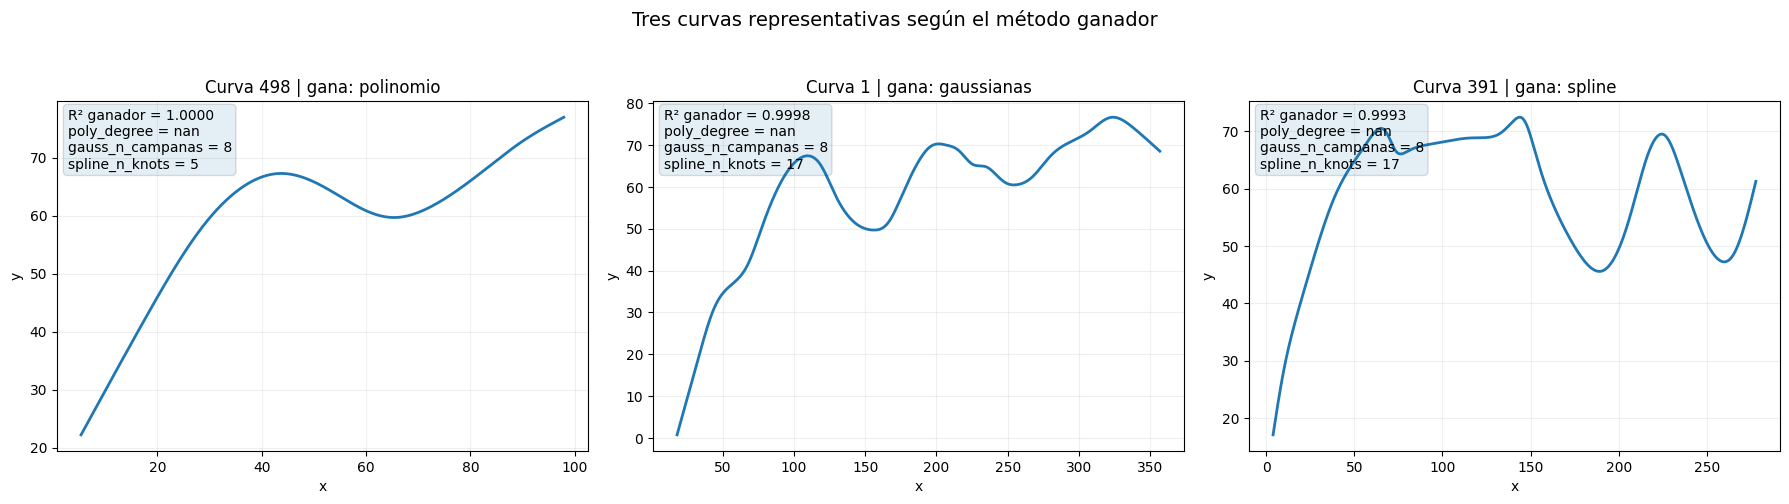

In [17]:
curvas_ejemplo = [498, 1, 391]
metodos_esperados = {498: 'polinomio', 1: 'gaussianas', 391: 'spline'}


def encontrar_archivo_curva(curva_id):
    candidatos = [
        f'curve_{curva_id:04d}.txt',
        f'curve_{curva_id}.txt',
    ]
    for nombre in candidatos:
        p = DATA_DIR / nombre
        if p.exists():
            return p
    return None


def leer_curva_txt(path):
    df_curve = pd.read_csv(path, header=None, names=['x', 'y'])
    return df_curve.sort_values('x').reset_index(drop=True)


meta = cmp[['curva', 'mejor_metodo', 'r2_mejor']].copy()
if 'poly_degree' in deg.columns:
    meta = meta.merge(deg[['curva', 'poly_degree']], on='curva', how='left')
if 'gauss_n_campanas' in cmp.columns:
    meta = meta.merge(cmp[['curva', 'gauss_n_campanas']], on='curva', how='left')
elif 'n_campanas' in gau.columns:
    meta = meta.merge(gau[['curva', 'n_campanas']].rename(columns={'n_campanas': 'gauss_n_campanas'}), on='curva', how='left')
if 'spline_n_knots' in cmp.columns:
    meta = meta.merge(cmp[['curva', 'spline_n_knots']], on='curva', how='left')

meta['ganador'] = meta['mejor_metodo']

faltantes = []
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=False)

for ax, curva_id in zip(axes, curvas_ejemplo):
    path = encontrar_archivo_curva(curva_id)
    if path is None:
        faltantes.append(curva_id)
        ax.text(0.5, 0.5, f'Archivo no encontrado\ncurve_{curva_id:04d}.txt',
                ha='center', va='center')
        ax.set_axis_off()
        continue

    curva_df = leer_curva_txt(path)
    fila_curva = meta[meta['curva'] == curva_id]

    if fila_curva.empty:
        ganador = metodos_esperados.get(curva_id, 'desconocido')
        r2_mejor = gauss_n_campanas = poly_degree = spline_n_knots = float('nan')
    else:
        fila = fila_curva.iloc[0]
        ganador = fila.get('ganador', metodos_esperados.get(curva_id, 'desconocido'))
        r2_mejor = fila.get('r2_mejor', float('nan'))
        poly_degree = fila.get('poly_degree', float('nan'))
        gauss_n_campanas = fila.get('gauss_n_campanas', float('nan'))
        spline_n_knots = fila.get('spline_n_knots', float('nan'))

    ax.plot(curva_df['x'], curva_df['y'], linewidth=2)
    ax.set_title(f'Curva {curva_id} | gana: {ganador}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    texto = (
        f'R² ganador = {r2_mejor:.4f}\n'
        f'poly_degree = {poly_degree}\n'
        f'gauss_n_campanas = {gauss_n_campanas}\n'
        f'spline_n_knots = {spline_n_knots}'
    )
    ax.text(0.02, 0.98, texto, transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', alpha=0.12))
    ax.grid(alpha=0.2)

plt.suptitle('Tres curvas representativas según el método ganador', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()


## 3. Integración de tablas y construcción de variables

## Definición formal de todas las métricas usadas

En esta sección se distinguen tres tipos de variables:

1. **Métricas de ajuste o error**: miden qué tan bien reproduce el modelo a la curva.
2. **Métricas de complejidad del modelo**: miden cuántos grados de libertad usa el ajuste.
3. **Métricas geométricas derivadas de la curva/modelo**: resumen la forma de la curva.

### A) Métricas de ajuste

#### 1. Coeficiente de determinación: $R^2$
Mide la proporción de variabilidad de la señal observada que es explicada por el modelo.

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i-\hat y_i)^2}{\sum_{i=1}^{n}(y_i-\bar y)^2}$$

#### 2. RMSE — Error cuadrático medio de la raíz

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2}$$

#### 3. MAE — Error absoluto medio

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|$$

#### 4. MAX\_AE — Error absoluto máximo

$$MAX\_AE = \max_i |y_i-\hat y_i|$$

### B) Métricas de complejidad del modelo

#### 5. Número de parámetros
#### 6. `poly_degree`: grado del polinomio
#### 7. `gauss_n_campanas`: número de campanas gaussianas
#### 8. `spline_n_knots`: número de nodos del spline

### C) Criterios de información

#### 9. AIC — Criterio de Información de Akaike
$$AIC = 2k - 2\ln(L)$$

#### 10. BIC — Criterio de Información Bayesiano
$$BIC = k\ln(n) - 2\ln(L)$$

### D) Parámetros del modelo gaussiano

$$\hat y(x)=c+\sum_{j=1}^{k} A_j\exp\left(-\frac{(x-\mu_j)^2}{2\sigma_j^2}\right)$$

- **$A_j$**: amplitud de la campana $j$
- **$\mu_j$**: centro de la campana $j$
- **$\sigma_j$**: ancho de la campana $j$
- **$c$**: offset (línea base)

### E) Métricas derivadas de forma

- `gauss_picos_significativos`: campanas con $A_j > 0.15 \cdot \max(A)$
- `gauss_dispersion_centros`: $\text{sd}(\mu_1,\ldots,\mu_k)$ ponderada por amplitud
- `gauss_sigma_media_pond`: $\bar\sigma_w = \sum A_j\sigma_j / \sum A_j$
- `indice_compacidad_picos`: picos significativos / dispersión de centros

### F) Métricas de estabilidad entre escalas

Promedios, máximos y desviaciones estándar de BIC, AIC y R² a través de las escalas X10, X15, X18, X21, X25.

### G) Variable objetivo

`ganador` / `mejor_metodo`: etiqueta del método con mejor desempeño en esa curva.

In [18]:
df = cmp.merge(deg, on='curva', how='left')

cols_gauss = ['curva', 'n_campanas', 'r2_gauss', 'c'] + \
             [c for c in gau.columns if c.startswith(('A_', 'mu_', 'sigma_'))]
df = df.merge(gau[cols_gauss], on='curva', how='left', suffixes=('', '_gauss_table'))

if 'mejor_metodo' not in df.columns:
    raise ValueError('No se encontró la columna mejor_metodo en comparacion_3_metodos.csv')

df['ganador'] = df['mejor_metodo']

for m in ['poly', 'gauss', 'spline']:
    df[f'gap_{m}'] = df['r2_mejor'] - df[f'{m}_r2']

bic_scale_cols = [c for c in df.columns if c.startswith('bic_X')]
aic_scale_cols = [c for c in df.columns if c.startswith('aic_X')]
r2_scale_cols  = [c for c in df.columns if c.startswith('r2_X')]

df['bic_std_escala'] = df[bic_scale_cols].std(axis=1)
df['aic_std_escala'] = df[aic_scale_cols].std(axis=1)
df['r2_std_escala']  = df[r2_scale_cols].std(axis=1)

A_cols     = sorted([c for c in df.columns if c.startswith('A_')],     key=lambda s: int(s.split('_')[1]))
mu_cols    = sorted([c for c in df.columns if c.startswith('mu_')],    key=lambda s: int(s.split('_')[1]))
sigma_cols = sorted([c for c in df.columns if c.startswith('sigma_')], key=lambda s: int(s.split('_')[1]))

A   = df[A_cols].fillna(0).to_numpy()
MU  = df[mu_cols].fillna(0).to_numpy()
SIG = df[sigma_cols].fillna(0).to_numpy()

Amax    = np.maximum(A.max(axis=1, keepdims=True), 1e-12)
weights = A.copy()
wsum    = np.maximum(weights.sum(axis=1), 1e-12)

mask_sig = (A >= 0.15 * Amax) & (A > 0)
df['gauss_picos_significativos'] = mask_sig.sum(axis=1)

mu_mean = (weights * MU).sum(axis=1) / wsum
mu_var  = (weights * (MU - mu_mean[:, None])**2).sum(axis=1) / wsum
df['gauss_dispersion_centros'] = np.sqrt(mu_var)

df['gauss_sigma_media_pond'] = (weights * SIG).sum(axis=1) / wsum
df['gauss_sigma_std_pond']   = np.sqrt(
    (weights * (SIG - df['gauss_sigma_media_pond'].to_numpy()[:, None])**2).sum(axis=1) / wsum
)
df['indice_compacidad_picos'] = df['gauss_picos_significativos'] / \
                                np.maximum(df['gauss_dispersion_centros'], 1e-6)

print(df.shape)
df[['curva', 'ganador', 'r2_mejor', 'poly_r2', 'gauss_r2', 'spline_r2',
    'poly_degree', 'gauss_n_campanas', 'spline_n_knots',
    'gauss_picos_significativos', 'gauss_dispersion_centros']].head()

(500, 82)


,curva,ganador,r2_mejor,poly_r2,gauss_r2,spline_r2,poly_degree,gauss_n_campanas,spline_n_knots,gauss_picos_significativos,gauss_dispersion_centros
0,1,gaussianas,0.9998,0.9986,0.9998,0.9996,14,8,17,5,102.2180
1,2,gaussianas,0.9998,0.9898,0.9998,0.9995,20,8,15,8,66.9064
2,3,gaussianas,1.0000,0.9997,1.0000,0.9998,20,8,11,5,61.3917
3,4,polinomio,1.0000,1.0000,1.0000,0.9993,20,8,5,7,29.5810
4,5,gaussianas,1.0000,0.9991,1.0000,0.9992,20,8,9,7,61.9113


## 4. ¿Quién gana más veces?

,metodo,n_curvas,porcentaje
0,gaussianas,314,62.8000
1,polinomio,109,21.8000
2,spline,77,15.4000


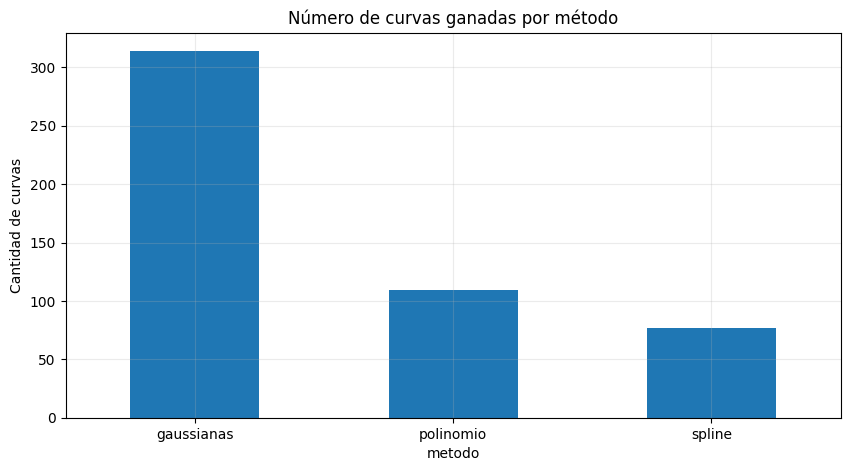

In [19]:
conteo = df['ganador'].value_counts().rename_axis('metodo').reset_index(name='n_curvas')
conteo['porcentaje'] = 100 * conteo['n_curvas'] / len(df)
display(conteo)

ax = conteo.set_index('metodo')['n_curvas'].plot(kind='bar', rot=0)
ax.set_title('Número de curvas ganadas por método')
ax.set_ylabel('Cantidad de curvas')
plt.show()

## 5. Perfil descriptivo por método ganador

In [ ]:
features_desc = [
    'poly_degree', 'gauss_n_campanas', 'spline_n_knots',
    'bic_promedio', 'aic_promedio', 'bic_max',
    'r2_promedio', 'r2_min', 'r2_std_escala',
    'gauss_picos_significativos', 'gauss_dispersion_centros',
    'gauss_sigma_media_pond', 'gauss_sigma_std_pond', 'indice_compacidad_picos']

perfil = df.groupby('ganador')[features_desc].agg(['median', 'mean'])
perfil

poly_degree         gauss_n_campanas        spline_n_knots          \
                median    mean           median   mean         median    mean   
ganador                                                                         
gaussianas     20.0000 19.3089           8.0000 7.9427        11.0000 11.5255   
polinomio      20.0000 19.3486           8.0000 7.8991         5.0000  5.0000   
spline         20.0000 19.3377           8.0000 7.8831        17.0000 17.3117   

           bic_promedio         aic_promedio         bic_max          \
                 median    mean       median    mean  median    mean   
ganador                                                                
gaussianas      19.0000 18.2045      19.3000 18.8611 20.0000 18.9172   
polinomio       12.6000 12.8257      14.0000 14.2606 14.0000 14.2569   
spline          19.6000 19.0701      19.8000 19.4701 20.0000 19.4545   

           r2_promedio        r2_min        r2_std_escala         \
                median   mean median   mean        median   mean   
ganador                                                            
gaussianas      0.9984 0.9972 0.9975 0.9962        0.0005 0.0007   
polinomio       0.9991 0.9979 0.9985 0.9963        0.0004 0.0012   
spline          0.9953 0.9937 0.9945 0.9927        0.0006 0.0007   

           gauss_picos_significativos        gauss_dispersion_centros          \
                               median   mean                   median    mean   
ganador                                                                         
gaussianas                     5.0000 5.3121                  57.5951 58.3738   
polinomio                      6.0000 5.3670                  27.3662 29.5364   
spline                         7.0000 6.5455                  83.2525 81.6447   

           gauss_sigma_media_pond         gauss_sigma_std_pond          \
                           median    mean               median    mean   
ganador                                                                  
gaussianas                24.6992 28.0314              10.6313 14.7631   
polinomio                 12.6446 14.5198               4.5885  6.3795   
spline                    24.0090 27.7208              10.8737 15.3239   

           indice_compacidad_picos         
                            median   mean  
ganador                                    
gaussianas                  0.0910 0.1006  
polinomio                   0.1941 0.2082  
spline                      0.0802 0.0826

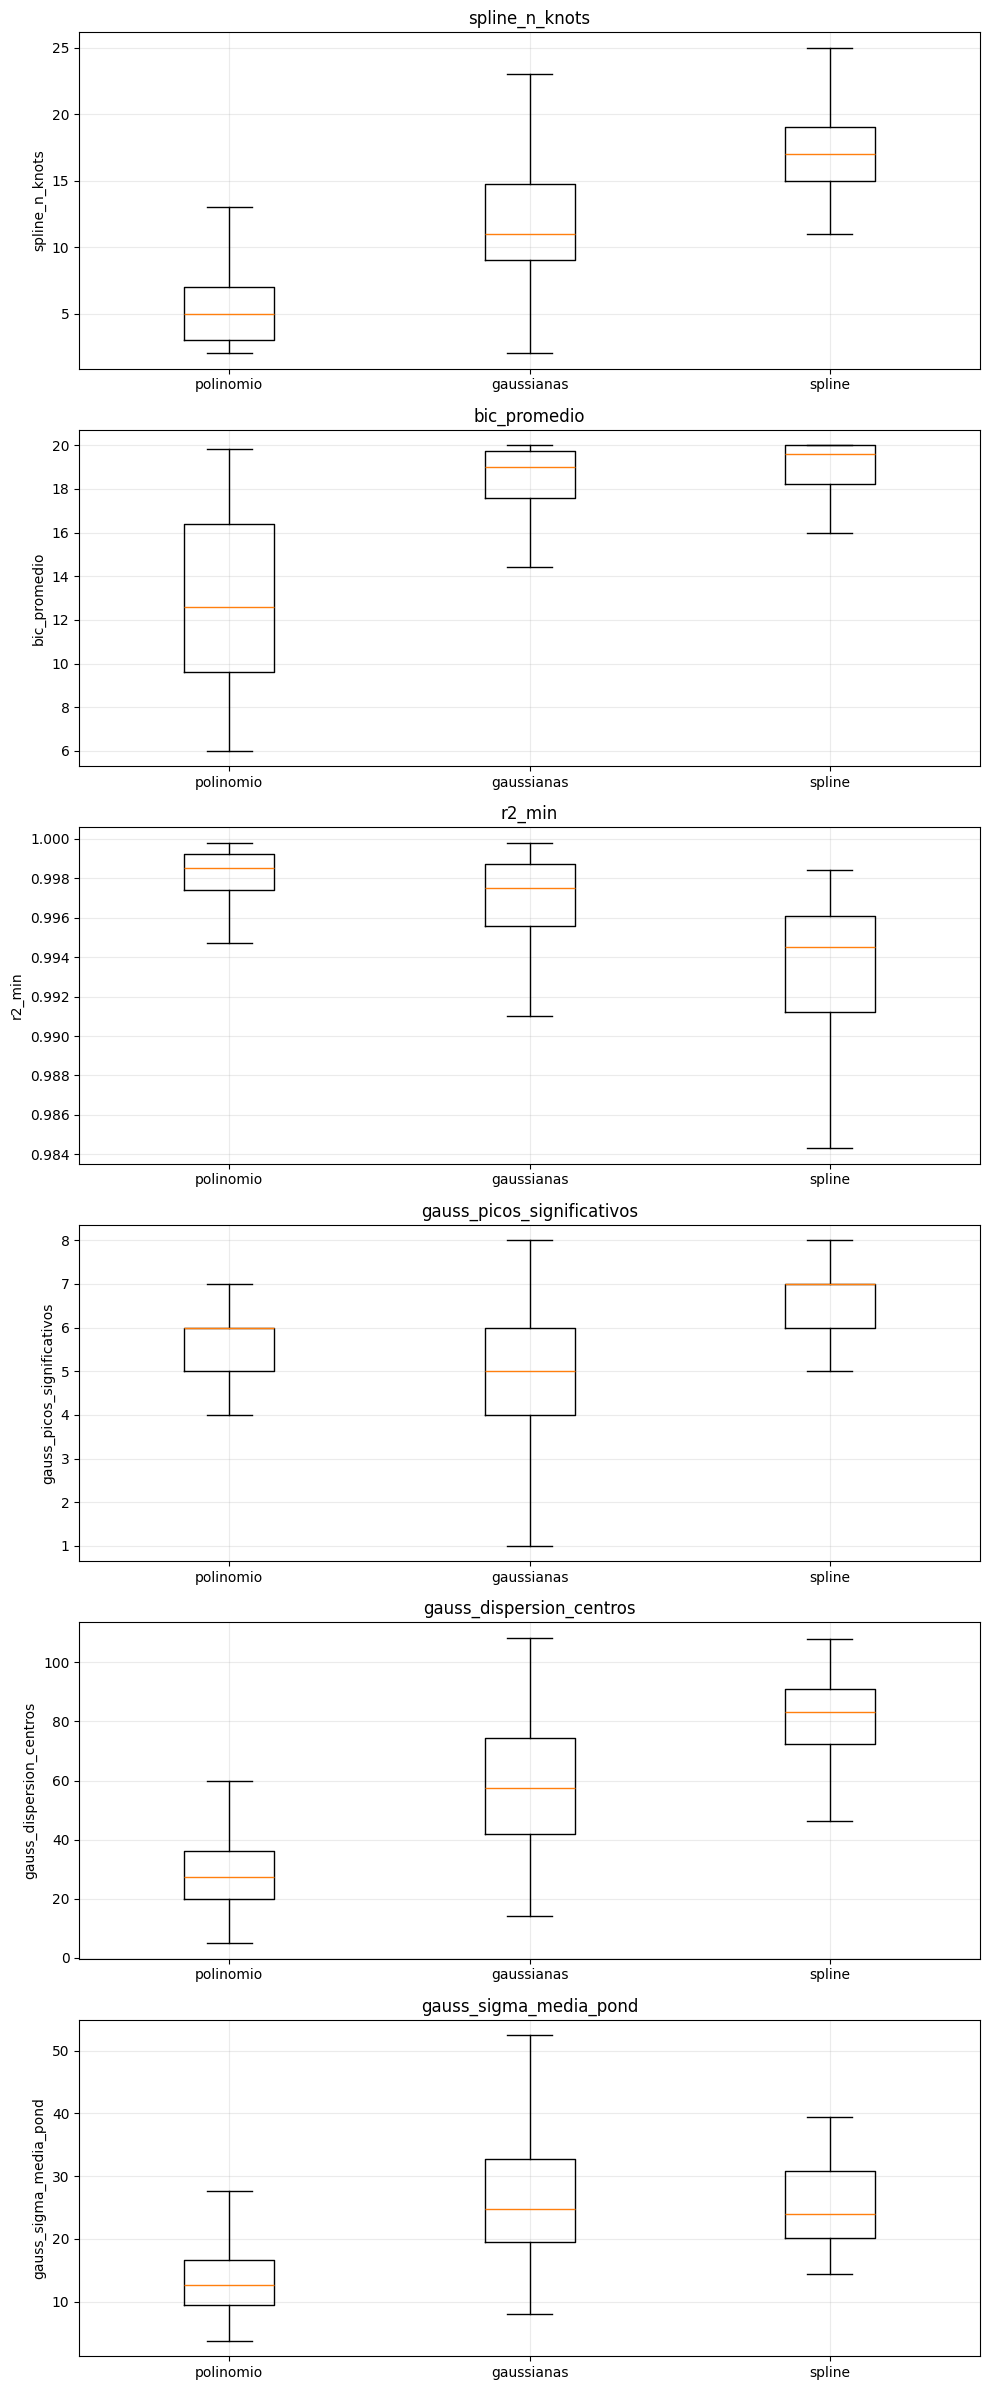

In [21]:
plot_features = [
    'spline_n_knots', 'bic_promedio', 'r2_min',
    'gauss_picos_significativos', 'gauss_dispersion_centros', 'gauss_sigma_media_pond'
]

fig, axes = plt.subplots(len(plot_features), 1, figsize=(10, 4 * len(plot_features)))

for ax, col in zip(axes, plot_features):
    groups = [df.loc[df['ganador'] == g, col].dropna()
              for g in ['polinomio', 'gaussianas', 'spline'] if g in df['ganador'].unique()]
    labels = [g for g in ['polinomio', 'gaussianas', 'spline'] if g in df['ganador'].unique()]
    ax.boxplot(groups, labels=labels, showfliers=False)
    ax.set_title(col)
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

## 6. Pruebas estadísticas: ¿qué variables cambian realmente entre ganadores?

In [22]:
resultados = []
for col in features_desc:
    grupos = [
        df.loc[df['ganador'] == metodo, col].dropna().values
        for metodo in ['polinomio', 'gaussianas', 'spline']
        if metodo in df['ganador'].unique()
    ]
    if all(len(g) > 0 for g in grupos):
        stat, p = kruskal(*grupos)
        resultados.append((col, stat, p))

stats_df = pd.DataFrame(resultados, columns=['variable', 'H', 'p_value'])
stats_df = stats_df.sort_values('p_value')
stats_df['significativa_0_05'] = stats_df['p_value'] < 0.05
stats_df

,variable,H,p_value,significativa_0_05
2,spline_n_knots,255.7749,0.0000,True
10,gauss_dispersion_centros,217.0139,0.0000,True
13,indice_compacidad_picos,182.7852,0.0000,True
3,bic_promedio,157.5310,0.0000,True
5,bic_max,152.6476,0.0000,True
4,aic_promedio,152.5475,0.0000,True
11,gauss_sigma_media_pond,146.1424,0.0000,True
6,r2_promedio,112.6664,0.0000,True
12,gauss_sigma_std_pond,104.5348,0.0000,True
7,r2_min,93.8220,0.0000,True


## 7. Modelo interpretable

Árbol de decisión (profundidad 3): modelo simple para extraer reglas legibles de cuándo gana cada método:

=== Árbol de decisión ===
              precision    recall  f1-score   support

  gaussianas       0.83      0.78      0.81        79
   polinomio       0.91      0.74      0.82        27
      spline       0.46      0.68      0.55        19

    accuracy                           0.76       125
   macro avg       0.73      0.74      0.72       125
weighted avg       0.79      0.76      0.77       125



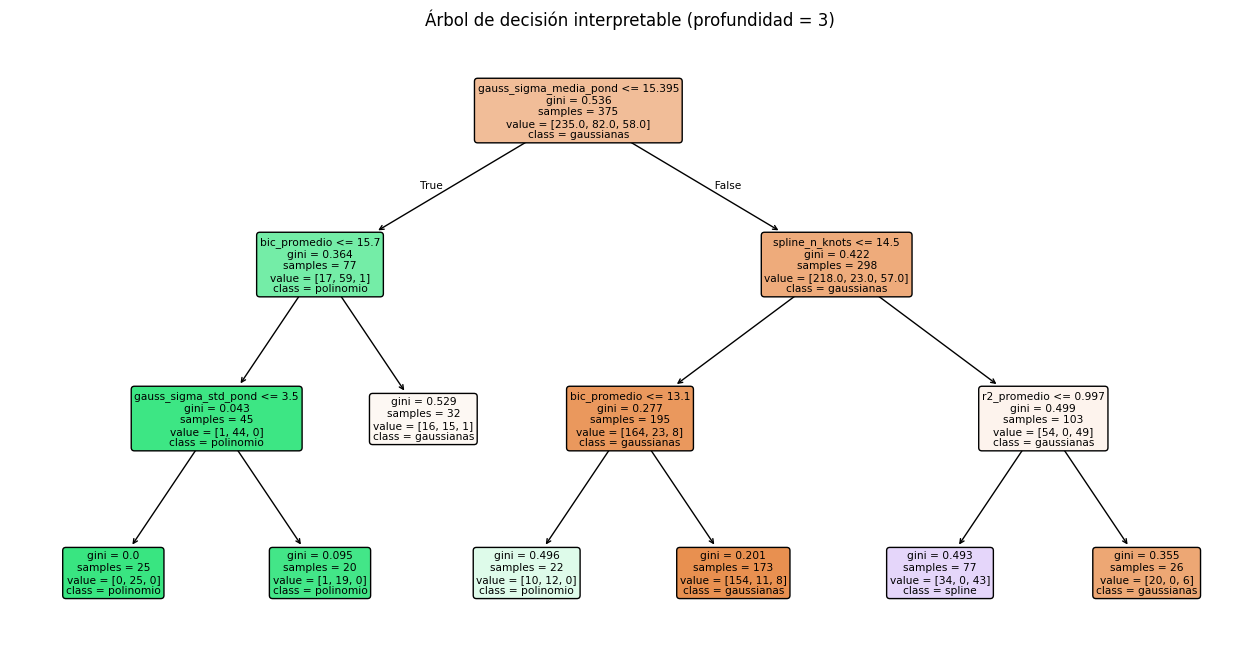

|--- gauss_sigma_media_pond <= 15.39
|   |--- bic_promedio <= 15.70
|   |   |--- gauss_sigma_std_pond <= 3.50
|   |   |   |--- class: polinomio
|   |   |--- gauss_sigma_std_pond >  3.50
|   |   |   |--- class: polinomio
|   |--- bic_promedio >  15.70
|   |   |--- class: gaussianas
|--- gauss_sigma_media_pond >  15.39
|   |--- spline_n_knots <= 14.50
|   |   |--- bic_promedio <= 13.10
|   |   |   |--- class: polinomio
|   |   |--- bic_promedio >  13.10
|   |   |   |--- class: gaussianas
|   |--- spline_n_knots >  14.50
|   |   |--- r2_promedio <= 1.00
|   |   |   |--- class: spline
|   |   |--- r2_promedio >  1.00
|   |   |   |--- class: gaussianas



In [23]:
features_modelo = [
    'spline_n_knots',
    'bic_promedio', 'bic_max', 'aic_promedio',
    'r2_promedio', 'r2_min', 'r2_std_escala',
    'gauss_picos_significativos',
    'gauss_dispersion_centros',
    'gauss_sigma_media_pond', 'gauss_sigma_std_pond',
    'indice_compacidad_picos'
]

X = df[features_modelo].copy()
y = df['ganador'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

arbol = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=42)
arbol.fit(X_train, y_train)
y_pred_tree = arbol.predict(X_test)

print('=== Árbol de decisión ===')
print(classification_report(y_test, y_pred_tree))

plt.figure(figsize=(16, 8))
plot_tree(arbol, feature_names=features_modelo,
          class_names=sorted(y.unique()), filled=True, rounded=True)
plt.title('Árbol de decisión interpretable (profundidad = 3)')
plt.show()

print(export_text(arbol, feature_names=features_modelo))

Random Forest (300 árboles): modelo más potente para confirmar importancia de variables:

=== Random Forest ===
              precision    recall  f1-score   support

  gaussianas       0.84      0.67      0.75        79
   polinomio       0.77      0.85      0.81        27
      spline       0.41      0.68      0.51        19

    accuracy                           0.71       125
   macro avg       0.67      0.74      0.69       125
weighted avg       0.76      0.71      0.72       125



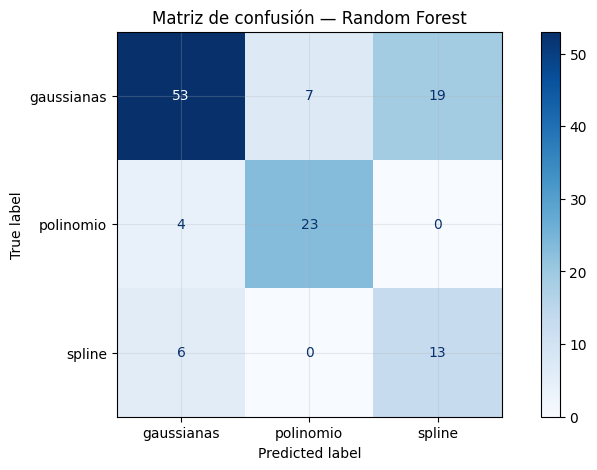

,feature,importance_mean,importance_std
2,bic_max,0.0188,0.0058
3,aic_promedio,0.0084,0.0103
1,bic_promedio,0.0076,0.0106
10,gauss_sigma_std_pond,-0.0036,0.0112
9,gauss_sigma_media_pond,-0.0080,0.0134
6,r2_std_escala,-0.0092,0.0058
7,gauss_picos_significativos,-0.0108,0.0108
11,indice_compacidad_picos,-0.0152,0.0087
0,spline_n_knots,-0.0168,0.0171
8,gauss_dispersion_centros,-0.0196,0.0230


In [24]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=5,
    random_state=42, class_weight='balanced'
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))

cm = confusion_matrix(y_test, y_pred_rf, labels=rf.classes_)
ConfusionMatrixDisplay(cm, display_labels=rf.classes_).plot(cmap='Blues')
plt.title('Matriz de confusión — Random Forest')
plt.show()

perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=42)
imp = pd.DataFrame({
    'feature': features_modelo,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

imp

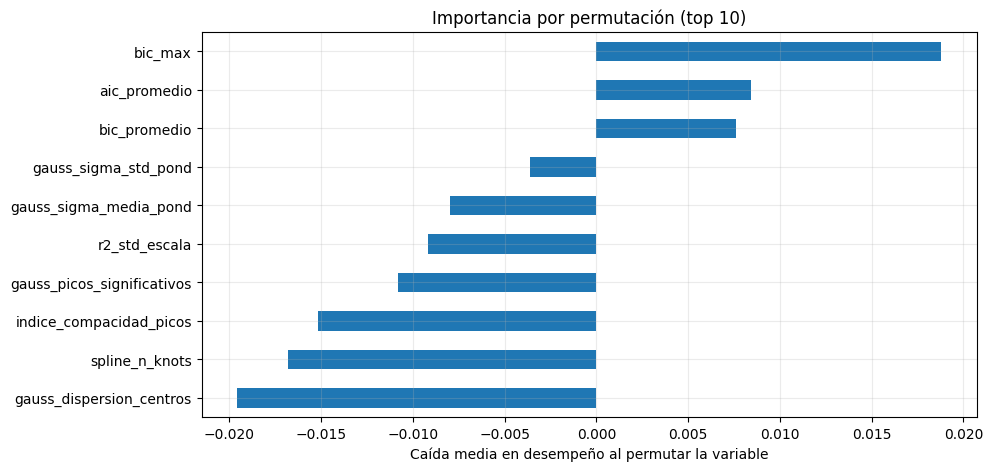

In [25]:
ax = imp.head(10).sort_values('importance_mean').plot(
    kind='barh', x='feature', y='importance_mean', legend=False
)
ax.set_title('Importancia por permutación (top 10)')
ax.set_xlabel('Caída media en desempeño al permutar la variable')
ax.set_ylabel('')
plt.show()

## 8. Síntesis

In [26]:
med = df.groupby('ganador')[[
    'spline_n_knots', 'bic_promedio', 'r2_min',
    'gauss_picos_significativos', 'gauss_dispersion_centros',
    'gauss_sigma_media_pond'
]].median()

imp_top = imp.head(6)['feature'].tolist()
print('Variables más explicativas según el modelo:', ', '.join(imp_top))
print()

if 'polinomio' in med.index:
    print('POLINOMIO:')
    print(f"- Tiende a ganar cuando la complejidad polinomial efectiva es menor "
          f"(bic_promedio mediano = {med.loc['polinomio', 'bic_promedio']:.2f}).")
    print(f"- Menos nudos spline (mediana = {med.loc['polinomio', 'spline_n_knots']:.0f}): geometría más suave y global.")
    print(f"- Menor dispersión de centros gaussianos ({med.loc['polinomio', 'gauss_dispersion_centros']:.2f}): estructura menos repartida.")
    print()

if 'gaussianas' in med.index:
    print('GAUSSIANAS:')
    print(f"- Gana en curvas de complejidad intermedia/alta "
          f"(bic_promedio mediano = {med.loc['gaussianas', 'bic_promedio']:.2f}).")
    print(f"- Varios picos relevantes (mediana = {med.loc['gaussianas', 'gauss_picos_significativos']:.0f}).")
    print(f"- Dispersión de centros intermedia ({med.loc['gaussianas', 'gauss_dispersion_centros']:.2f}).")
    print()

if 'spline' in med.index:
    print('SPLINE:')
    print(f"- Gana cuando la curva requiere muchos nudos "
          f"(mediana = {med.loc['spline', 'spline_n_knots']:.0f}).")
    print(f"- Mayor dispersión espacial de centros ({med.loc['spline', 'gauss_dispersion_centros']:.2f}): variación local más rica.")

Variables más explicativas según el modelo: bic_max, aic_promedio, bic_promedio, gauss_sigma_std_pond, gauss_sigma_media_pond, r2_std_escala

POLINOMIO:
- Tiende a ganar cuando la complejidad polinomial efectiva es menor (bic_promedio mediano = 12.60).
- Menos nudos spline (mediana = 5): geometría más suave y global.
- Menor dispersión de centros gaussianos (27.37): estructura menos repartida.

GAUSSIANAS:
- Gana en curvas de complejidad intermedia/alta (bic_promedio mediano = 19.00).
- Varios picos relevantes (mediana = 5).
- Dispersión de centros intermedia (57.60).

SPLINE:
- Gana cuando la curva requiere muchos nudos (mediana = 17).
- Mayor dispersión espacial de centros (83.25): variación local más rica.


## 9. Conclusión final

Con este análisis, la respuesta a la pregunta central queda así:

### 1) ¿Cuándo tiende a ganar el polinomio?
Cuando la curva parece tener una **estructura global más simple**, más suave y con menor complejidad efectiva. En estas curvas, el número de nudos que necesitaría un spline es bajo y la geometría parece más concentrada.

### 2) ¿Cuándo tienden a ganar las gaussianas?
Cuando la curva tiene una forma que puede representarse bien como **suma de picos/campanas**, con complejidad intermedia o alta, pero todavía con una organización relativamente compatible con una descomposición en componentes gaussianas.

### 3) ¿Cuándo tiende a ganar el spline?
Cuando la curva tiene **variación local más rica**, distribuida a lo largo del dominio, y por tanto requiere más flexibilidad. Eso se refleja en un mayor número de nudos y en una mayor dispersión de la estructura interna.

## RESUMEN

> **El método ganador también depende de la geometría de la curva.**
>
> - **Menor complejidad global / forma más regular (suave)** → **polinomio**.
> - **Presencia de picos compatibles con campanas** → **gaussianas**.
> - **Mayor complejidad local y estructura repartida** → **spline**.
